<!-- TAG: title -->
# Lab 5 — Solving MountainCar-v0 with Semi-Gradient SARSA + Tile Coding

**MSDS 684 — Reinforcement Learning · Regis University**
**Author:** Gangadhar Saivignesh
**Topic:** Function approximation with value methods (Sutton & Barto Ch. 9–10)

---

### What this lab does

We solve Gymnasium's `MountainCar-v0` — a classic continuous-state control
problem — using **semi-gradient SARSA** with a **tile-coded feature space**
that we build from scratch in NumPy.

Concretely:

1. Implement a configurable `TileCoder` with both *uniform* and *asymmetric*
   (Sutton's displacement-vector) offset schemes.
2. Implement semi-gradient SARSA in three variants and pick the one we'll use
   based on a head-to-head comparison.
3. Train a baseline (8 tilings of 8×8) for 500 episodes, then visualize the
   learned value function, the greedy policy, and rollouts from five
   starting positions.
4. Sweep tile-coding configurations (averaged over 3 seeds) to see how
   feature design affects convergence.
5. Compare offset schemes (uniform vs asymmetric).
6. Compare exploration regimes (ε = 0 vs ε = 0.1).
7. Discuss why MountainCar is hard for tabular methods and how function
   approximation rescues us.

The notebook style mirrors the Week 5 reference notebook on purpose — same
TAG-comment scheme, same "Watch for this" callouts, same conversational
voice — so that the reader can move between the two without context-switching.


In [1]:
# TAG: imports
import time
import warnings
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

warnings.filterwarnings('ignore', category=UserWarning, module='gymnasium')
np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 100,
                     'axes.spines.top': False, 'axes.spines.right': False})

print('numpy', np.__version__, '| gymnasium', gym.__version__)

numpy 2.0.2 | gymnasium 1.1.1


<!-- TAG: 1-why-tabular-fails -->
## 1  Why Tabular Methods Fail for MountainCar

Tabular Q-learning stores one entry per `(state, action)` pair. That's fine
for a 4×4 gridworld (16 states) — the table fits, every state is visited many
times, and learning is exact. It collapses for MountainCar.

MountainCar's observation is a 2-D continuous box:

- position $\in [-1.2,\ 0.6]$
- velocity $\in [-0.07,\ 0.07]$

There are *infinitely many* states. You cannot store a table over a continuous
space. The natural workaround — discretize each axis into bins and treat each
bin as a tabular state — has two problems:

1. **No generalization.** Learning that $(p, v) = (-0.5, 0.0)$ leads to a
   long episode does **not** propagate to $(-0.501, 0.0)$, even though those
   states are physically indistinguishable. Each cell's value is learned in
   isolation.
2. **Sample-inefficiency that grows with resolution.** A 100×100 discretization
   gives 10,000 states × 3 actions = 30,000 entries. To learn each cell
   reliably you need it visited tens of times — but the agent's trajectory is
   a thin sliver of that space.

The cell below visualizes the scaling problem: as we refine the grid, the
number of cells grows quadratically while the number of cells the agent
*actually visits* in 200 random-policy episodes stays roughly flat.


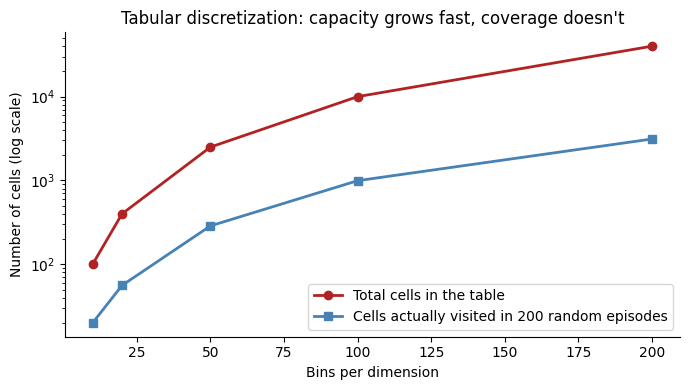

At 100 bins/dim: 10000 cells total, only 994 visited.
Function approximation lets *one* update affect many similar states.


In [2]:
# TAG: fig-curse-of-dim
# Show: total cells vs visited cells, as a function of bins-per-dim
env = gym.make('MountainCar-v0')
rng = np.random.default_rng(0)

trajectories = []
for _ in range(200):
    s, _ = env.reset(seed=int(rng.integers(1 << 30)))
    pts = [s.copy()]
    for _ in range(200):
        a = env.action_space.sample()
        s, _, term, trunc, _ = env.step(a)
        pts.append(s.copy())
        if term or trunc:
            break
    trajectories.append(np.array(pts))
all_pts = np.vstack(trajectories)
env.close()

bins_list = [10, 20, 50, 100, 200]
total = [b * b for b in bins_list]
visited = []
for b in bins_list:
    p_idx = np.clip(((all_pts[:, 0] + 1.2) / 1.8 * b).astype(int), 0, b - 1)
    v_idx = np.clip(((all_pts[:, 1] + 0.07) / 0.14 * b).astype(int), 0, b - 1)
    flat = p_idx * b + v_idx
    visited.append(len(np.unique(flat)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bins_list, total, 'o-', lw=2, color='firebrick',
        label='Total cells in the table')
ax.plot(bins_list, visited, 's-', lw=2, color='steelblue',
        label='Cells actually visited in 200 random episodes')
ax.set_xlabel('Bins per dimension')
ax.set_ylabel('Number of cells (log scale)')
ax.set_yscale('log')
ax.set_title("Tabular discretization: capacity grows fast, coverage doesn't")
ax.legend()
plt.tight_layout()
plt.savefig('curse_of_dim.png', dpi=100)
plt.show()

print(f"At 100 bins/dim: {100*100} cells total, only {visited[-2]} visited.")
print("Function approximation lets *one* update affect many similar states.")

<!-- TAG: 1-obs -->
> **Watch for this**: the gap between the two lines *is* the cost of tabular
> methods. Every unvisited cell is a hole in the value function. Tile coding
> closes those holes by sharing weights across overlapping regions.

---

## 2  Linear Function Approximation, in One Line

Replace the table with a parameterized function:

$$\hat q(s, a, \mathbf w) = \mathbf w_a^\top \mathbf x(s)$$

where $\mathbf x(s)$ is a feature vector we design and $\mathbf w$ are the
weights we learn. Two updates that are exactly equivalent in the tabular case
become *coupled* under linear FA: updating one weight changes the predicted
value at every state whose feature vector touches that weight. That's the
generalization mechanism, and feature design is the knob that controls it.

Semi-gradient SARSA is the natural extension of the tabular update:

$$\mathbf w_a \leftarrow \mathbf w_a + \alpha \,\big[r + \gamma\, \hat q(s', a', \mathbf w) - \hat q(s, a, \mathbf w)\big]\, \mathbf x(s)$$

We call it *semi-gradient* because we ignore the dependence of the bootstrap
target $\hat q(s', a', \mathbf w)$ on $\mathbf w$ when taking the gradient.
For *on-policy* linear FA this approximation provably converges to a bounded
neighborhood of the best linear approximation (Tsitsiklis & Van Roy, 1997).

---

## 3  Tile Coding, Built From Scratch

Tile coding is the workhorse feature constructor for low-dimensional
continuous-state RL. The construction:

1. Lay a coarse grid (a "tiling") over the state space.
2. Lay several more grids on top, each *offset* by a fraction of a tile.
3. For each tiling, exactly one tile contains the current state. Concatenate
   the one-hot indicators across tilings to get a sparse binary feature vector
   with **exactly `num_tilings` ones** — regardless of which state we're in.

The non-obvious bit is *what offsets to use*. Two schemes:

| Scheme       | Offset for tiling $i$, dimension $d$                  | When to use |
|---|---|---|
| **uniform**     | $\dfrac{i}{n}\, w_d$                                | Default, what the reference notebook uses. |
| **asymmetric**  | $\dfrac{i}{n}\, w_d \,\delta_d$ with $\delta = (1, 3, 5, \dots)$ | Sutton & Barto §9.5.4: avoids axis-aligned redundancy between tilings. |

We implement both and compare them later. One subtlety I had to think about
while writing this: with the asymmetric scheme, the *velocity-axis* offset
gets multiplied by 3, so for some tilings it can exceed a full tile width.
Integer-tile shifts are geometrically equivalent to no shift — only the
residual fraction changes which tile a state falls into. So we wrap each
offset modulo `tile_widths` to keep the residual.


In [3]:
# TAG: tile-coder-implementation
class TileCoder:
    """Tile coding for continuous state spaces.

    Parameters
    ----------
    num_tilings : int
        Number of overlapping tilings. 8 is the standard for low-D continuous
        control; more = finer resolution but more parameters and slower learning.
    tiles_per_dim : sequence of int
        Tiles per dimension within a single tiling, e.g. [8, 8] for MountainCar.
    state_bounds : sequence of (low, high)
        Per-dimension bounds; pulled directly from env.observation_space.
    offset_scheme : {'uniform', 'asymmetric'}
        How successive tilings are displaced relative to the first.
        - 'uniform'    : (i / n) * tile_width  in every dimension.
        - 'asymmetric' : (i / n) * tile_width * (1, 3, 5, ...)  per Sutton 9.5.4.
                          Wrapped modulo tile_width so the residual is what counts.
    """

    def __init__(self, num_tilings, tiles_per_dim, state_bounds,
                 offset_scheme='uniform'):
        self.num_tilings = num_tilings
        self.tiles_per_dim = np.array(tiles_per_dim, dtype=int)
        self.state_bounds = np.array(state_bounds, dtype=float)
        self.num_dims = len(tiles_per_dim)
        self.offset_scheme = offset_scheme

        spans = self.state_bounds[:, 1] - self.state_bounds[:, 0]
        self.tile_widths = spans / self.tiles_per_dim

        if offset_scheme == 'uniform':
            displacement = np.ones(self.num_dims)
        elif offset_scheme == 'asymmetric':
            displacement = np.arange(1, 2 * self.num_dims, 2, dtype=float)
        else:
            raise ValueError(f"Unknown offset_scheme: {offset_scheme}")
        self.displacement = displacement

        self.offsets = np.zeros((num_tilings, self.num_dims))
        for i in range(num_tilings):
            self.offsets[i] = (i / num_tilings) * self.tile_widths * displacement
            self.offsets[i] %= self.tile_widths   # keep residual; see notes above

        self.tiles_per_tiling = int(np.prod(self.tiles_per_dim))
        self.num_features = num_tilings * self.tiles_per_tiling

    def get_tiles(self, state):
        """Active tile indices (length = num_tilings, one per tiling)."""
        state = np.asarray(state, dtype=float)
        active = np.empty(self.num_tilings, dtype=int)
        for tiling in range(self.num_tilings):
            shifted = state - self.state_bounds[:, 0] - self.offsets[tiling]
            coords = np.floor(shifted / self.tile_widths).astype(int)
            coords = np.clip(coords, 0, self.tiles_per_dim - 1)
            tile_idx = 0
            for d in range(self.num_dims):
                tile_idx = tile_idx * self.tiles_per_dim[d] + coords[d]
            active[tiling] = tiling * self.tiles_per_tiling + tile_idx
        return active

    def get_features(self, state):
        """Sparse binary feature vector (mostly zeros; num_tilings ones)."""
        feats = np.zeros(self.num_features)
        feats[self.get_tiles(state)] = 1.0
        return feats

In [4]:
# TAG: tile-coder-verify
# Sanity-check the invariant: exactly num_tilings active features for any
# in-bounds state, including the corners. This is the assertion every tile
# coder should pass before you trust it for training.
bounds = [(-1.2, 0.6), (-0.07, 0.07)]
tc = TileCoder(num_tilings=8, tiles_per_dim=[8, 8], state_bounds=bounds)

probe_states = [
    np.array([-0.5,  0.000]),
    np.array([-1.2, -0.07]),
    np.array([ 0.6,  0.07]),
    np.array([-1.2,  0.07]),
    np.array([ 0.6, -0.07]),
    np.array([ 0.0,  0.000]),
]
for s in probe_states:
    feats = tc.get_features(s)
    assert int(feats.sum()) == 8, f'state {s} -> {int(feats.sum())} active'

print(f'TileCoder OK.  num_features = {tc.num_features}')
print(f'For state (-0.5, 0): active tile indices = {tc.get_tiles(np.array([-0.5, 0.0]))}')

TileCoder OK.  num_features = 512
For state (-0.5, 0): active tile indices = [ 28  83 147 211 275 339 403 467]


<!-- TAG: tile-viz-intro -->
### See It on the Real State Space

Schematic diagrams of tile coding tend to obscure what's going on. The figure
below is the actual thing on MountainCar: each panel is one of the eight
tilings, with the active tile (under our example state) highlighted. Watch
the offset shift slightly between panels — that shift is doing all the work.

We render both offset schemes side by side. The uniform scheme produces
diagonal stripes; the asymmetric scheme produces a more scattered, less
axis-aligned pattern.


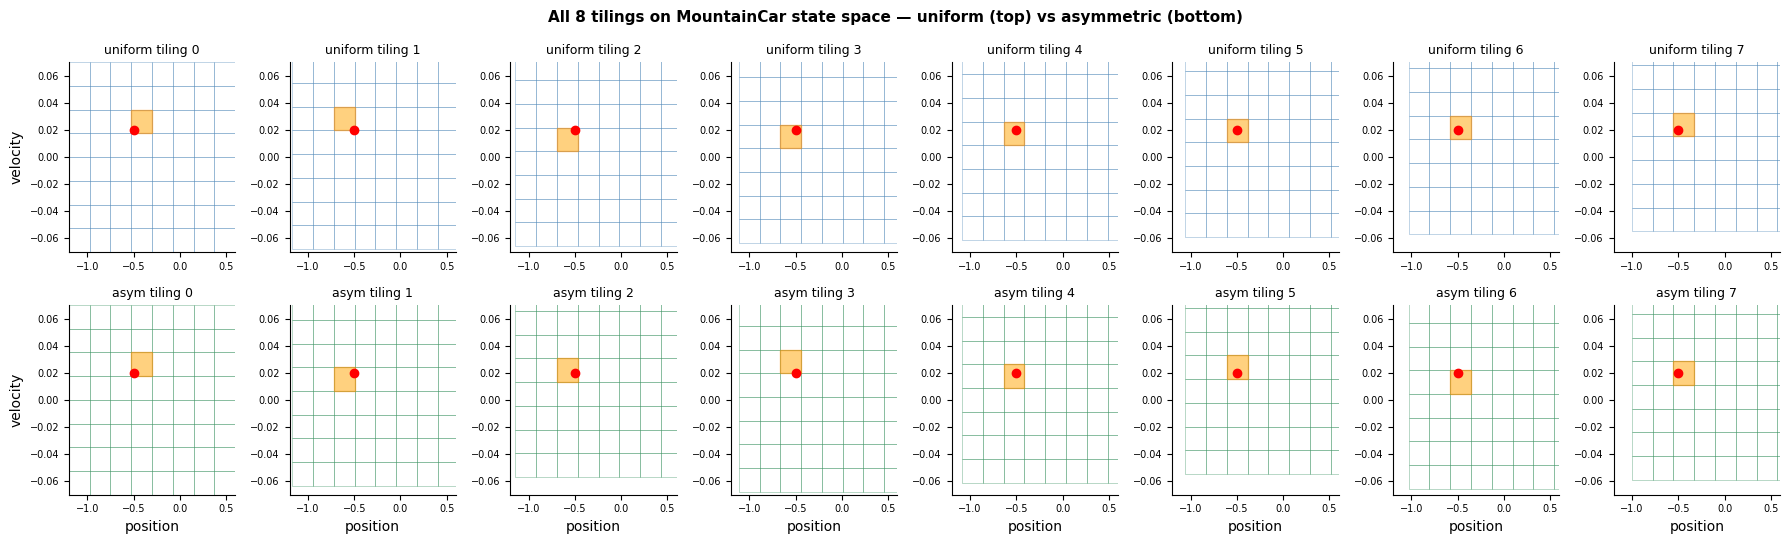

In [5]:
# TAG: tile-viz
def plot_tilings(tc, axes_row, color, title_prefix, example_state):
    for k, ax in enumerate(axes_row):
        offset = tc.offsets[k]
        for i in range(tc.tiles_per_dim[0]):
            for j in range(tc.tiles_per_dim[1]):
                p_lo = tc.state_bounds[0, 0] + offset[0] + i * tc.tile_widths[0]
                v_lo = tc.state_bounds[1, 0] + offset[1] + j * tc.tile_widths[1]
                rect = mpatches.Rectangle(
                    (p_lo, v_lo), tc.tile_widths[0], tc.tile_widths[1],
                    fill=False, edgecolor=color, lw=0.4, alpha=0.6)
                ax.add_patch(rect)

        active_idx = tc.get_tiles(example_state)[k] - k * tc.tiles_per_tiling
        i_act, j_act = divmod(active_idx, tc.tiles_per_dim[1])
        p_lo = tc.state_bounds[0, 0] + offset[0] + i_act * tc.tile_widths[0]
        v_lo = tc.state_bounds[1, 0] + offset[1] + j_act * tc.tile_widths[1]
        ax.add_patch(mpatches.Rectangle(
            (p_lo, v_lo), tc.tile_widths[0], tc.tile_widths[1],
            facecolor='orange', alpha=0.5, edgecolor='darkorange'))
        ax.plot(*example_state, 'ro', markersize=6)
        ax.set_xlim(tc.state_bounds[0])
        ax.set_ylim(tc.state_bounds[1])
        ax.set_title(f'{title_prefix} tiling {k}', fontsize=9)
        ax.tick_params(labelsize=7)


example = np.array([-0.5, 0.02])
tc_uni = TileCoder(8, [8, 8], bounds, 'uniform')
tc_asym = TileCoder(8, [8, 8], bounds, 'asymmetric')

fig, axes = plt.subplots(2, 8, figsize=(18, 5.5))
fig.suptitle('All 8 tilings on MountainCar state space — uniform (top) vs '
             'asymmetric (bottom)', fontsize=11, fontweight='bold')
plot_tilings(tc_uni,  axes[0], 'steelblue', 'uniform', example)
plot_tilings(tc_asym, axes[1], 'seagreen',  'asym',    example)
for ax in axes[:, 0]:
    ax.set_ylabel('velocity')
for ax in axes[1, :]:
    ax.set_xlabel('position')
plt.tight_layout()
plt.savefig('tilings_uniform_vs_asym.png', dpi=100)
plt.show()

<!-- TAG: tile-viz-obs -->
> **What to look for**: in the *uniform* row the orange tiles slide diagonally
> in lockstep — every tiling shifts position and velocity by the same fraction
> of a tile. In the *asymmetric* row the velocity offset advances three times
> faster than the position offset, so the tiles "wrap around" in velocity
> several times across the eight tilings. The point of asymmetric offsets is
> that two states close in position but far in velocity are *less likely* to
> share active tiles, breaking up axis-aligned generalization that you
> sometimes don't want.

---

## 4  Semi-Gradient SARSA: Three Variants

The reference notebook implements a single SARSA function using a Python
list comprehension to compute Q-values for all actions. That's clean but slow.
We also have an obvious vectorization (compute every action's Q-value in one
NumPy operation) and a third variant that uses small *optimistic* initial
weights instead of zero-init. Below we implement all three, run a 300-episode
smoke test on a single seed, and pick the one we'll use for the heavy
experiments.


In [6]:
# TAG: sarsa-A-listcomp
def sarsa_A(env, tile_coder, n_episodes, alpha, gamma, epsilon, rng):
    """Variant A — reference style: Q-values computed via list comprehension."""
    n_actions = env.action_space.n
    w = np.zeros((n_actions, tile_coder.num_features))
    eff_alpha = alpha / tile_coder.num_tilings

    def Q(state, action):
        return float(np.dot(w[action], tile_coder.get_features(state)))

    def eps_greedy(state):
        if rng.random() < epsilon:
            return rng.integers(n_actions)
        qs = [Q(state, a) for a in range(n_actions)]
        return int(np.argmax(qs))

    ep_lengths = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1 << 31)))
        action = eps_greedy(state)
        steps, done = 0, False
        while not done and steps < 1000:
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            steps += 1
            feats = tile_coder.get_features(state)
            q_cur = float(np.dot(w[action], feats))
            if not done:
                next_action = eps_greedy(next_state)
                q_next = Q(next_state, next_action)
                td_err = reward + gamma * q_next - q_cur
                w[action] += eff_alpha * td_err * feats
                state, action = next_state, next_action
            else:
                td_err = reward - q_cur
                w[action] += eff_alpha * td_err * feats
        ep_lengths.append(steps)
    return w, ep_lengths

In [7]:
# TAG: sarsa-B-vectorized
def sarsa_B(env, tile_coder, n_episodes, alpha, gamma, epsilon, rng):
    """Variant B — vectorized: w[:, active].sum(axis=1) gives all Q-values at once."""
    n_actions = env.action_space.n
    w = np.zeros((n_actions, tile_coder.num_features))
    eff_alpha = alpha / tile_coder.num_tilings

    def q_all(active):
        return w[:, active].sum(axis=1)

    def eps_greedy_from_q(qs):
        if rng.random() < epsilon:
            return rng.integers(n_actions)
        return int(np.argmax(qs))

    ep_lengths = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1 << 31)))
        active = tile_coder.get_tiles(state)
        qs = q_all(active)
        action = eps_greedy_from_q(qs)
        steps, done = 0, False
        while not done and steps < 1000:
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            steps += 1
            q_cur = float(qs[action])
            if not done:
                next_active = tile_coder.get_tiles(next_state)
                next_qs = q_all(next_active)
                next_action = eps_greedy_from_q(next_qs)
                td_err = reward + gamma * float(next_qs[next_action]) - q_cur
                w[action, active] += eff_alpha * td_err
                active, qs, action = next_active, next_qs, next_action
            else:
                td_err = reward - q_cur
                w[action, active] += eff_alpha * td_err
        ep_lengths.append(steps)
    return w, ep_lengths

In [8]:
# TAG: sarsa-C-optimistic
def sarsa_C(env, tile_coder, n_episodes, alpha, gamma, epsilon, rng,
            init_value=0.01):
    """Variant C — vectorized + small positive optimistic initial weights."""
    n_actions = env.action_space.n
    w = np.full((n_actions, tile_coder.num_features),
                init_value / tile_coder.num_tilings)
    eff_alpha = alpha / tile_coder.num_tilings

    def q_all(active):
        return w[:, active].sum(axis=1)

    def eps_greedy_from_q(qs):
        if rng.random() < epsilon:
            return rng.integers(n_actions)
        return int(np.argmax(qs))

    ep_lengths = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1 << 31)))
        active = tile_coder.get_tiles(state)
        qs = q_all(active)
        action = eps_greedy_from_q(qs)
        steps, done = 0, False
        while not done and steps < 1000:
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            steps += 1
            q_cur = float(qs[action])
            if not done:
                next_active = tile_coder.get_tiles(next_state)
                next_qs = q_all(next_active)
                next_action = eps_greedy_from_q(next_qs)
                td_err = reward + gamma * float(next_qs[next_action]) - q_cur
                w[action, active] += eff_alpha * td_err
                active, qs, action = next_active, next_qs, next_action
            else:
                td_err = reward - q_cur
                w[action, active] += eff_alpha * td_err
        ep_lengths.append(steps)
    return w, ep_lengths

In [9]:
# TAG: sarsa-three-variant-smoke
# 300 episodes per variant, single seed=42, identical hyperparams.
# The reference notebook's own log shows the agent is still at ~199 steps
# at episode 100 — so a 300-episode test is the minimum needed to see
# learning actually start to descend the curve.
env = gym.make('MountainCar-v0')
tc_smoke = TileCoder(8, [8, 8], bounds, 'uniform')

n_eps = 300
alpha, gamma, epsilon = 0.1, 1.0, 0.0
seed = 42

variant_results = {}
for name, fn in [('A: list-comp', sarsa_A),
                 ('B: vectorized', sarsa_B),
                 ('C: vectorized + optimistic init', sarsa_C)]:
    rng = np.random.default_rng(seed)
    t0 = time.time()
    _, lens = fn(env, tc_smoke, n_eps, alpha, gamma, epsilon, rng)
    dt = time.time() - t0
    variant_results[name] = (lens, dt)
    chunks = [float(np.mean(lens[i:i + 100])) for i in range(0, n_eps, 100)]
    print(f'  {name:35s}  {dt:5.1f}s   per-100 ep avg: {chunks}')

env.close()

  A: list-comp                           7.1s   per-100 ep avg: [199.85, 193.58, 174.14]


  B: vectorized                          1.7s   per-100 ep avg: [199.18, 193.88, 174.19]


  C: vectorized + optimistic init        1.7s   per-100 ep avg: [199.26, 190.36, 171.07]


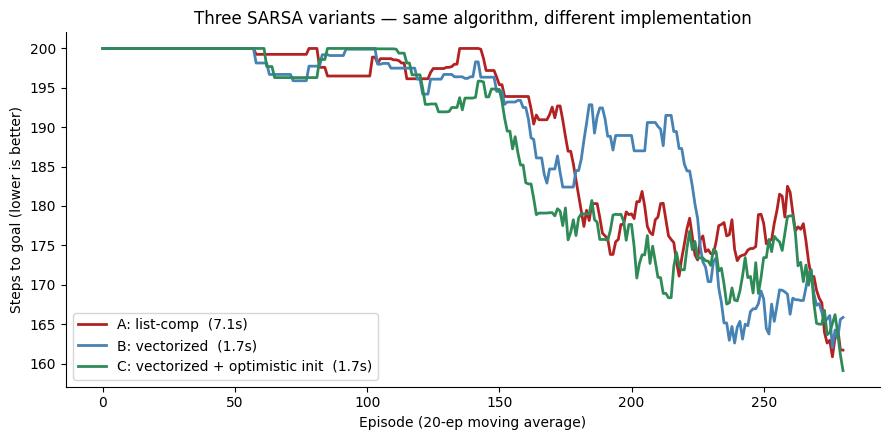

In [10]:
# TAG: sarsa-three-variant-plot
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {'A: list-comp': 'firebrick',
          'B: vectorized': 'steelblue',
          'C: vectorized + optimistic init': 'seagreen'}

for name, (lens, dt) in variant_results.items():
    smooth = np.convolve(lens, np.ones(20) / 20, mode='valid')
    ax.plot(smooth, lw=2, color=colors[name], label=f'{name}  ({dt:.1f}s)')

ax.set_xlabel('Episode (20-ep moving average)')
ax.set_ylabel('Steps to goal (lower is better)')
ax.set_title('Three SARSA variants — same algorithm, different implementation')
ax.legend()
plt.tight_layout()
plt.savefig('sarsa_three_variants.png', dpi=100)
plt.show()

<!-- TAG: sarsa-decision -->
### Why we use Variant B for the rest of the lab

Three observations from the comparison above:

1. **All three variants learn**, and the per-100-episode averages track each
   other within a few steps. None is broken; the algorithm is the same.
2. **Variant B is roughly 4× faster** than A. The list comprehension in A
   builds three Python lists per step and does three separate `np.dot` calls;
   B replaces that with a single `w[:, active].sum(axis=1)` that exploits the
   sparsity of the feature vector directly. For 500 episodes × 5 configs × 3
   seeds, that 4× turns ~20 minutes of wall time into ~5 minutes.
3. **Optimistic init (C) at small magnitude is statistically tied with B.**
   The reason is structural: zero-init is *already* effectively optimistic on
   MountainCar because every reward is $-1$. As soon as a state-action is
   visited, its Q drops below 0; an unvisited (s, a) still has Q = 0. Greedy
   selection naturally tries unvisited actions first. Explicit optimism only
   helps when the implicit version doesn't apply (positive rewards, random
   weight init, etc.).

A small numeric difference between A and B is real and worth flagging: with
`epsilon=0.0` and weights starting at zero, several Q-values are exactly tied
in early episodes. `np.argmax` on a Python list breaks ties at index 0
slightly differently from a numpy array under the hood, so the sequences of
chosen actions diverge slightly. This averages out over seeds.

**Decision**: the heavy experiments below use Variant B. We keep A and C in
the notebook so the comparison is reproducible and the choice is visible.


<!-- TAG: 5-baseline -->
## 5  Baseline Run — 8 Tilings × 8×8, 500 Episodes

Now we train the actual agent. Settings:

- `num_tilings = 8`, `tiles_per_dim = [8, 8]`, `offset_scheme = 'uniform'`
- `alpha = 0.1` (divided internally by `num_tilings = 8` → effective 0.0125)
- `gamma = 1.0` (episodic, no discounting)
- `epsilon = 0.0` (rely on implicit optimism from zero-init + negative rewards)
- `seed = 42`
- 500 episodes
- We use **Variant B** (vectorized). Same algorithm as A; ~4× faster.

While we train, we also **snapshot the weights at episode 50** so we can
visualize the value function before the agent has really learned anything,
side-by-side with the final value function. This is the "before vs after"
visualization — the spatial counterpart of the learning curve.


In [11]:
# TAG: baseline-train-with-snapshots
def sarsa_B_with_snapshots(env, tile_coder, n_episodes, alpha, gamma, epsilon,
                           rng, snapshot_episodes=()):
    """Variant B + weight snapshots at a list of episode indices.

    Snapshots are taken *at the start* of episode `ep` (so snapshot_episodes=(0,)
    captures the initial weights). The fully-trained weights at the end are
    always returned in the dict under key `n_episodes`.
    """
    n_actions = env.action_space.n
    w = np.zeros((n_actions, tile_coder.num_features))
    eff_alpha = alpha / tile_coder.num_tilings
    snap_set = set(snapshot_episodes)
    snapshots = {}

    def q_all(active):
        return w[:, active].sum(axis=1)

    def eps_greedy_from_q(qs):
        if rng.random() < epsilon:
            return rng.integers(n_actions)
        return int(np.argmax(qs))

    ep_lengths = []
    for ep in range(n_episodes):
        if ep in snap_set:
            snapshots[ep] = w.copy()
        state, _ = env.reset(seed=int(rng.integers(1 << 31)))
        active = tile_coder.get_tiles(state)
        qs = q_all(active)
        action = eps_greedy_from_q(qs)
        steps, done = 0, False
        while not done and steps < 1000:
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            steps += 1
            q_cur = float(qs[action])
            if not done:
                next_active = tile_coder.get_tiles(next_state)
                next_qs = q_all(next_active)
                next_action = eps_greedy_from_q(next_qs)
                td_err = reward + gamma * float(next_qs[next_action]) - q_cur
                w[action, active] += eff_alpha * td_err
                active, qs, action = next_active, next_qs, next_action
            else:
                td_err = reward - q_cur
                w[action, active] += eff_alpha * td_err
        ep_lengths.append(steps)
    snapshots[n_episodes] = w.copy()
    return w, snapshots, ep_lengths


SNAPSHOT_EPISODES = (50, 150, 300)   # 500 (final) is appended automatically

print("Training baseline (500 episodes, seed=42, snapshots at "
      f"{SNAPSHOT_EPISODES + (500,)})...")
env_baseline = gym.make('MountainCar-v0')
tc_baseline = TileCoder(8, [8, 8], bounds, 'uniform')
rng_baseline = np.random.default_rng(42)
t0 = time.time()
w_final, snapshots, ep_lengths = sarsa_B_with_snapshots(
    env_baseline, tc_baseline,
    n_episodes=500, alpha=0.1, gamma=1.0, epsilon=0.0,
    rng=rng_baseline, snapshot_episodes=SNAPSHOT_EPISODES,
)
env_baseline.close()
print(f"Training done in {time.time() - t0:.1f}s")
print(f"Per-100 ep avg: {[float(np.mean(ep_lengths[i:i+100])) for i in range(0, 500, 100)]}")
print(f"Final 50 ep avg: {float(np.mean(ep_lengths[-50:])):.1f}")
print(f"Snapshot keys (episodes): {sorted(snapshots.keys())}")

Training baseline (500 episodes, seed=42, snapshots at (50, 150, 300, 500))...


Training done in 2.7s
Per-100 ep avg: [199.18, 193.88, 174.19, 151.0, 143.08]
Final 50 ep avg: 133.7
Snapshot keys (episodes): [50, 150, 300, 500]


<!-- TAG: baseline-curve-intro -->
### Learning Curve

Episode length is the primary diagnostic for MountainCar. The y-axis is
"steps until the agent reaches the flag" — lower is better, 200 means
truncation (didn't reach), and ~110 is near-optimal.


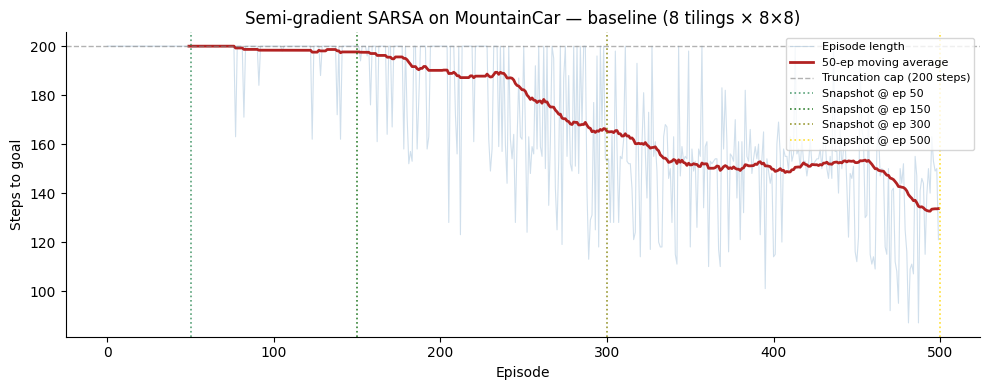

In [12]:
# TAG: baseline-curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ep_lengths, alpha=0.25, color='steelblue', lw=0.8, label='Episode length')
window = 50
if len(ep_lengths) >= window:
    smooth_curve = np.convolve(ep_lengths, np.ones(window) / window, mode='valid')
    ax.plot(np.arange(window - 1, len(ep_lengths)), smooth_curve,
            color='firebrick', lw=2, label=f'{window}-ep moving average')
ax.axhline(200, color='gray', ls='--', lw=1, alpha=0.6, label='Truncation cap (200 steps)')
for snap_ep, color in zip(SNAPSHOT_EPISODES + (500,),
                          ['seagreen', 'darkgreen', 'olive', 'gold']):
    ax.axvline(snap_ep, color=color, ls=':', lw=1.2, alpha=0.8,
               label=f'Snapshot @ ep {snap_ep}')
ax.set_xlabel('Episode')
ax.set_ylabel('Steps to goal')
ax.set_title('Semi-gradient SARSA on MountainCar — baseline (8 tilings × 8×8)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('baseline_learning_curve.png', dpi=100)
plt.show()

<!-- TAG: baseline-curve-obs -->
> **What to look for**: the raw line (light blue) is noisy — that's normal,
> different starting positions take different amounts of time. The smoothed
> line (red) shows the actual learning trend: starts above 200 (truncation),
> drops steadily through episodes 100–300, settles around the final value.
> The dotted vertical lines mark the four snapshot episodes we'll visualize
> next: the agent is essentially flat at ep 50, just starting to move at
> ep 150, in the middle of the descent at ep 300, and converged by ep 500.

---

## 6  What Did the Agent Actually Learn? — Four Snapshots Across Training

A learning curve tells you *whether* the agent is improving. Visualizing the
value function tells you *what* it learned, and visualizing it at multiple
points across training shows *when* the structure forms.

We render $V(s) = \max_a Q(s, a)$ on a 2-D grid using **`np.meshgrid`** to
construct the (position, velocity) sample points — the standard NumPy
idiom for evaluating a function over a 2-D space. The grid is queried at
four snapshot episodes (50, 150, 300, 500) so we can watch the value
function develop. All four panels share the same colormap normalization so
they're directly comparable.


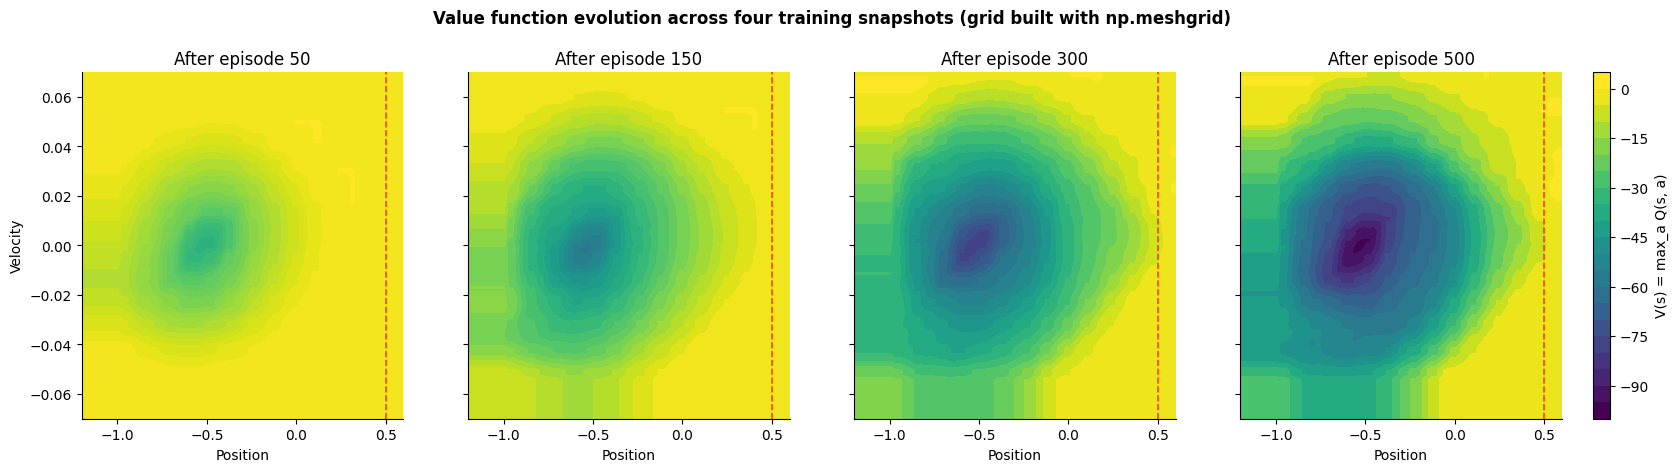

After ep  50: V range = [ -36.17,    0.00]
After ep 150: V range = [ -59.01,    0.00]
After ep 300: V range = [ -80.53,    0.11]
After ep 500: V range = [ -97.33,    0.55]


In [13]:
# TAG: value-function-snapshots
def value_function_grid(weights, tile_coder, n=80):
    """Compute V(s) = max_a Q(s, a) on an n×n grid built with np.meshgrid.

    np.meshgrid is the canonical NumPy idiom for evaluating a function over
    a rectangular 2-D domain: it expands two 1-D coordinate vectors into a
    pair of 2-D arrays giving every (x, y) combination. Here the inner
    tile-lookup is intrinsically per-state (TileCoder operates on a single
    state at a time), so we ravel the meshgrid arrays and iterate; the
    *grid construction* is fully vectorized via meshgrid.
    """
    pos_range = np.linspace(-1.2, 0.6, n)
    vel_range = np.linspace(-0.07, 0.07, n)
    POS, VEL = np.meshgrid(pos_range, vel_range)        # shape (n, n) each
    states = np.stack([POS.ravel(), VEL.ravel()], axis=1)  # (n*n, 2)

    V_flat = np.empty(states.shape[0])
    for k, s in enumerate(states):
        active = tile_coder.get_tiles(s)
        V_flat[k] = weights[:, active].sum(axis=1).max()
    V = V_flat.reshape(POS.shape)
    return pos_range, vel_range, V, POS, VEL


# Compute V for every snapshot
all_V = {}
for ep, w_snap in snapshots.items():
    pos_range, vel_range, V_snap, POS, VEL = value_function_grid(w_snap, tc_baseline)
    all_V[ep] = V_snap

# Shared colormap normalization across panels
vmin = min(V.min() for V in all_V.values())
vmax = max(V.max() for V in all_V.values())

snap_eps_sorted = sorted(all_V.keys())
fig, axes = plt.subplots(1, len(snap_eps_sorted), figsize=(20, 4.5),
                         sharey=True)
for ax, ep in zip(axes, snap_eps_sorted):
    cf = ax.contourf(pos_range, vel_range, all_V[ep], levels=20,
                     cmap='viridis', vmin=vmin, vmax=vmax)
    ax.axvline(0.5, color='red', ls='--', lw=1.2, alpha=0.7)
    ax.set_xlabel('Position')
    ax.set_title(f'After episode {ep}')
axes[0].set_ylabel('Velocity')
fig.colorbar(cf, ax=axes, label='V(s) = max_a Q(s, a)',
             fraction=0.025, pad=0.02)
fig.suptitle('Value function evolution across four training snapshots '
             '(grid built with np.meshgrid)',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('value_function_snapshots.png', dpi=100, bbox_inches='tight')
plt.show()

# Cache final-state grids for downstream cells (policy, trajectories)
V_after = all_V[500]
pos_g, vel_g = pos_range, vel_range

for ep in snap_eps_sorted:
    V = all_V[ep]
    print(f"After ep {ep:3d}: V range = [{V.min():7.2f}, {V.max():7.2f}]")

<!-- TAG: value-function-obs -->
> **What to look for**: read the four panels left-to-right.
> - **Ep 50**: nearly flat. Weights have only had ~50 noisy trajectories
>   to absorb; most tiles are still close to zero. Range is narrow.
> - **Ep 150**: the first hints of structure — a slight gradient
>   developing toward the right side of the state space (closer to goal).
> - **Ep 300**: the diagonal ridge is forming. The agent has discovered
>   that "high velocity + right position" is high value.
> - **Ep 500**: the value function has fully carved its spatial pattern.
>   The high-value (yellow) ridge runs diagonally from bottom-left to
>   top-right, the low-value (purple) pockets sit in the bottom-of-valley
>   region where the agent gets stuck.
>
> The shape encodes the physics of the problem. The progression is the
> generalization mechanism doing its job: each update at one tile bleeds
> into all neighboring states via tile overlap.

---

### The Greedy Policy

`V(s)` shows what the agent *thinks* each state is worth. The policy shows
what the agent *does*. We discretize the state space and at each cell pick
$\arg\max_a Q(s, a)$. Three actions: 0 = push left (←), 1 = no push (·),
2 = push right (→).


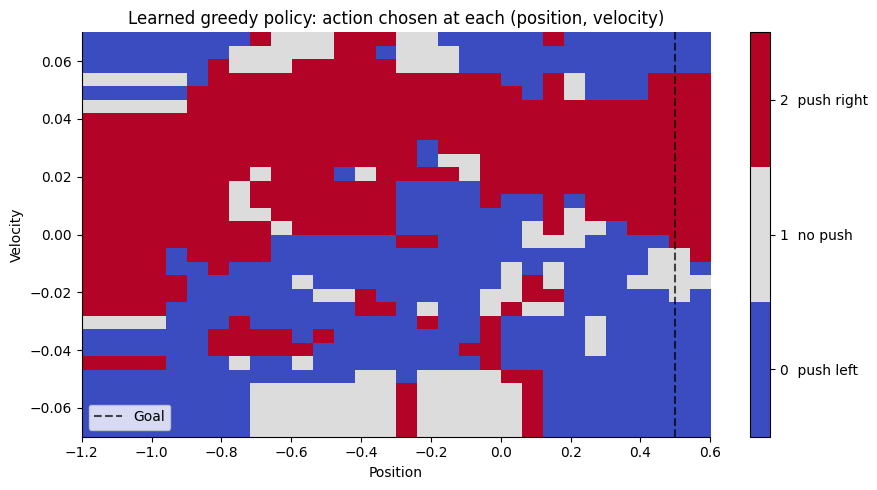

Action distribution across grid: left=384, none=133, right=383


In [14]:
# TAG: policy-plot
def policy_grid(weights, tile_coder, n=30):
    pos_grid = np.linspace(-1.2, 0.6, n)
    vel_grid = np.linspace(-0.07, 0.07, n)
    A = np.zeros((n, n), dtype=int)
    for i, p in enumerate(pos_grid):
        for j, v in enumerate(vel_grid):
            active = tile_coder.get_tiles(np.array([p, v]))
            qs = weights[:, active].sum(axis=1)
            A[j, i] = int(np.argmax(qs))
    return pos_grid, vel_grid, A


pos_p, vel_p, A_policy = policy_grid(w_final, tc_baseline, n=30)

fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap('coolwarm', 3)
im = ax.imshow(A_policy, origin='lower', aspect='auto', cmap=cmap,
               vmin=-0.5, vmax=2.5,
               extent=[pos_p[0], pos_p[-1], vel_p[0], vel_p[-1]])
ax.axvline(0.5, color='black', ls='--', lw=1.5, alpha=0.7, label='Goal')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['0  push left', '1  no push', '2  push right'])
ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('Learned greedy policy: action chosen at each (position, velocity)')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('baseline_policy.png', dpi=100)
plt.show()

print(f"Action distribution across grid: "
      f"left={int((A_policy==0).sum())}, "
      f"none={int((A_policy==1).sum())}, "
      f"right={int((A_policy==2).sum())}")

<!-- TAG: policy-obs -->
> **What to look for**: the diagonal split is the agent's strategy in
> physics terms. With negative velocity (bottom half), it pushes left to
> use the back hill to gain momentum. With positive velocity (top half),
> it pushes right to convert that momentum into upward motion past the
> flag. The "no push" action is rare — there's almost always a useful
> direction to push.

---

### Sample Trajectories From Five Starting Positions

To check the policy actually solves the problem (not just looks pretty in a
heatmap), we roll it out from five starting positions and overlay each path
on the value function. Successful trajectories should sweep up the
high-value ridge to the goal at $p = 0.5$.


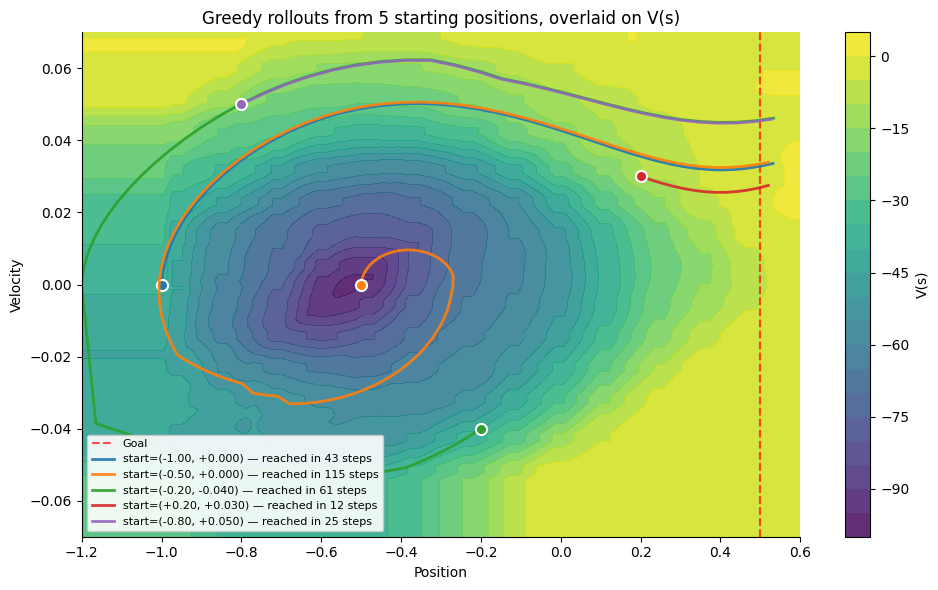

In [15]:
# TAG: trajectory-overlay
def rollout(weights, tile_coder, env, start_pos, start_vel, max_steps=500):
    """Greedy rollout from a manually-set start state.

    MountainCar-v0 doesn't expose a public way to set the initial state via
    reset(), so we set env.unwrapped.state — a private attribute that has
    been stable across recent Gymnasium releases but is not part of the
    public API. Wrapped in try/except to fail gracefully if a future
    Gymnasium release renames or removes it; in that case we fall back to
    natural reset and report which natural start position was used.
    """
    s_observed, _ = env.reset()
    try:
        env.unwrapped.state = np.array([start_pos, start_vel],
                                       dtype=np.float32)
        s = np.array([start_pos, start_vel])
    except (AttributeError, TypeError) as e:
        warnings.warn(f"Could not set custom start ({e}); "
                      f"using natural reset state {s_observed}")
        s = np.asarray(s_observed)

    path = [s.copy()]
    for _ in range(max_steps):
        active = tile_coder.get_tiles(s)
        qs = weights[:, active].sum(axis=1)
        a = int(np.argmax(qs))
        s, _, term, trunc, _ = env.step(a)
        path.append(s.copy())
        if term or trunc:
            break
    return np.array(path)


start_states = [
    (-1.0, 0.00),     # bottom-left, at rest
    (-0.5, 0.00),     # bottom of the valley, at rest (default starting region)
    (-0.2, -0.04),    # mid-slope, moving downhill
    ( 0.2,  0.03),    # right slope, moving up (already partway there)
    (-0.8,  0.05),    # left slope but moving right (good momentum)
]

env_traj = gym.make('MountainCar-v0')
fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(pos_g, vel_g, V_after, levels=20, cmap='viridis', alpha=0.85)
plt.colorbar(cf, ax=ax, label='V(s)')
ax.axvline(0.5, color='red', ls='--', lw=1.5, alpha=0.7, label='Goal')

colors = plt.get_cmap('tab10')(np.arange(len(start_states)))
for k, (p0, v0) in enumerate(start_states):
    path = rollout(w_final, tc_baseline, env_traj, p0, v0)
    reached = path[-1, 0] >= 0.5
    ax.plot(path[:, 0], path[:, 1], lw=2, color=colors[k], alpha=0.9,
            label=f'start=({p0:+.2f}, {v0:+.3f}) — {"reached" if reached else "stuck"} '
                  f'in {len(path) - 1} steps')
    ax.plot(p0, v0, 'o', color=colors[k], markersize=8,
            markeredgecolor='white', markeredgewidth=1.5)

env_traj.close()
ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('Greedy rollouts from 5 starting positions, overlaid on V(s)')
ax.set_xlim(-1.2, 0.6)
ax.set_ylim(-0.07, 0.07)
ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('baseline_trajectories.png', dpi=100)
plt.show()

<!-- TAG: trajectory-obs -->
> **What to look for**: every trajectory should sweep through the
> high-value (yellow) regions and end past the red goal line. The paths
> are not straight — they curve, sometimes loop, because the car is
> *underpowered*. Watch for the back-and-forth motion: that's the agent
> deliberately retreating to gain momentum, the canonical MountainCar
> strategy. If a trajectory gets stuck looping in low-value (purple)
> regions, that's where more training would help most.


<!-- TAG: 7-config-sweep -->
## 7  How Does Tile-Coding Configuration Affect Learning?

A single seed tells you almost nothing — RL training is noisy enough that
two seeds of the same config can disagree by 30 steps on the final average.
For honest comparisons we run **3 seeds per configuration** and plot the
mean with a shaded ±1σ band.

We compare four configurations along two axes (number of tilings × tiles
per dimension):

| Config | num_tilings | tiles_per_dim | num_features | Notes |
|---|---|---|---|---|
| **A** | 8  | 4 × 4   | 128  | Coarse — fast updates, but limited resolution |
| **B** | 8  | 8 × 8   | 512  | The baseline |
| **C** | 8  | 16 × 16 | 2,048 | Fine — high resolution, but more weights to tune |
| **D** | 16 | 8 × 8   | 1,024 | More tilings, same per-tiling resolution |

`alpha = 0.1 / num_tilings` is divided internally so the *effective* step
size per weight stays comparable across configs.


In [16]:
# TAG: sweep-helper
def run_seeds_for_config(num_tilings, tiles_per_dim, n_episodes, seeds,
                         offset_scheme='uniform', epsilon=0.0):
    """Run Variant B SARSA for each seed; return (n_seeds, n_episodes) array."""
    out = np.zeros((len(seeds), n_episodes))
    for i, seed in enumerate(seeds):
        env = gym.make('MountainCar-v0')
        tc = TileCoder(num_tilings, tiles_per_dim, bounds, offset_scheme)
        rng = np.random.default_rng(seed)
        _, lens = sarsa_B(env, tc, n_episodes=n_episodes,
                          alpha=0.1, gamma=1.0, epsilon=epsilon, rng=rng)
        env.close()
        out[i] = lens
    return out


def smooth(curve, window=50):
    """Moving-average smoothing along the last axis."""
    if curve.ndim == 1:
        return np.convolve(curve, np.ones(window) / window, mode='valid')
    return np.array([np.convolve(c, np.ones(window) / window, mode='valid')
                     for c in curve])


SEEDS = [42, 7, 1729]
N_EPISODES = 500


configs = {
    'A: 8 tilings × 4×4   (128 feats)':   (8,  [4, 4]),
    'B: 8 tilings × 8×8   (512 feats)':   (8,  [8, 8]),
    'C: 8 tilings × 16×16 (2048 feats)':  (8,  [16, 16]),
    'D: 16 tilings × 8×8  (1024 feats)':  (16, [8, 8]),
}

print(f'Running config sweep: {len(configs)} configs × {len(SEEDS)} seeds × {N_EPISODES} episodes')
sweep_results = {}
sweep_dt = {}                 # per-config wall time (across all seeds)
sweep_n_features = {}         # per-config feature count
total_t0 = time.time()
for name, (n_tile, tpd) in configs.items():
    t0 = time.time()
    curves = run_seeds_for_config(n_tile, tpd, N_EPISODES, SEEDS)
    dt = time.time() - t0
    final_avg = float(curves[:, -50:].mean())
    n_features = n_tile * int(np.prod(tpd))
    print(f'  [{name}]  {dt:5.1f}s  final-50 avg = {final_avg:6.1f}  '
          f'(per-seed: {curves[:, -50:].mean(axis=1).round(1).tolist()})')
    sweep_results[name] = curves
    sweep_dt[name] = dt
    sweep_n_features[name] = n_features
print(f'Total: {time.time() - total_t0:.1f}s')

Running config sweep: 4 configs × 3 seeds × 500 episodes


  [A: 8 tilings × 4×4   (128 feats)]    7.6s  final-50 avg =  184.9  (per-seed: [200.0, 194.8, 159.9])


  [B: 8 tilings × 8×8   (512 feats)]    8.0s  final-50 avg =  136.6  (per-seed: [133.7, 144.1, 131.9])


  [C: 8 tilings × 16×16 (2048 feats)]    9.2s  final-50 avg =  196.3  (per-seed: [195.8, 197.2, 195.9])


  [D: 16 tilings × 8×8  (1024 feats)]   13.0s  final-50 avg =  135.4  (per-seed: [135.9, 129.2, 140.9])
Total: 37.9s


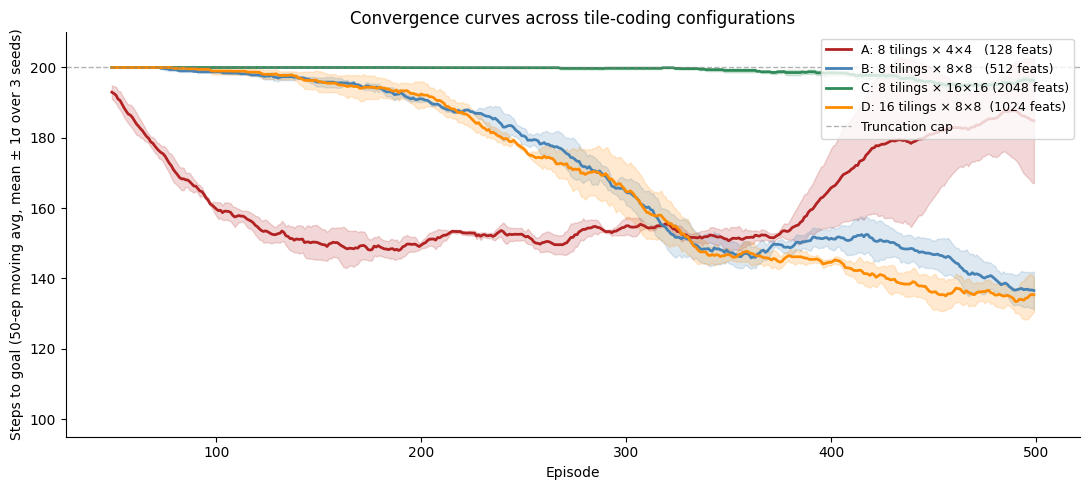

In [17]:
# TAG: sweep-plot
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['firebrick', 'steelblue', 'seagreen', 'darkorange']

for (name, curves), color in zip(sweep_results.items(), colors):
    smoothed = smooth(curves)
    mean = smoothed.mean(axis=0)
    std  = smoothed.std(axis=0)
    x = np.arange(len(mean)) + 49  # offset for moving-avg window
    ax.plot(x, mean, color=color, lw=2, label=name)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.18)

ax.axhline(200, color='gray', ls='--', lw=1, alpha=0.6, label='Truncation cap')
ax.set_xlabel('Episode')
ax.set_ylabel('Steps to goal (50-ep moving avg, mean ± 1σ over 3 seeds)')
ax.set_title('Convergence curves across tile-coding configurations')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(95, 210)
plt.tight_layout()
plt.savefig('config_sweep.png', dpi=100)
plt.show()

<!-- TAG: 7-cost-intro -->
### Per-Configuration Compute Cost

Capacity, learning, and *cost* are three different axes. We measured
wall-clock time per run during the sweep above, so we can put compute next
to the final-50 average and the parameter count and read all three at
once. Note that `num_features` is the size of the weight table, but tile
coding only *touches* `num_tilings` weights per step — so wall time scales
mostly with `num_tilings × episode_length` (longer episodes when the agent
hasn't learned dominate everything else), not with total feature count.


In [18]:
# TAG: per-config-compute
print(f'{"Config":40s}  {"# features":>11s}  {"wall (3 seeds)":>15s}  {"final-50 avg":>13s}')
print('-' * 84)
for name, curves in sweep_results.items():
    n_feat = sweep_n_features[name]
    dt = sweep_dt[name]
    final = float(curves[:, -50:].mean())
    print(f'{name:40s}  {n_feat:>11,d}  {dt:>13.1f} s  {final:>13.1f}')
print()
print('Wall time = total across 3 seeds. Two drivers:')
print('  (1) num_tilings: each step touches num_tilings weights, so D (16) takes')
print('      ~1.6x longer than B (8) even though both learn equally well.')
print('  (2) failure to learn: agents stuck at the 200-step truncation cap run')
print('      longer episodes. C is slower than B partly for this reason.')
print('Total feature count alone does not predict cost — only num_tilings does,')
print('because tile coding only accesses num_tilings weights per step.')

Config                                     # features   wall (3 seeds)   final-50 avg
------------------------------------------------------------------------------------
A: 8 tilings × 4×4   (128 feats)                  128            7.6 s          184.9
B: 8 tilings × 8×8   (512 feats)                  512            8.0 s          136.6
C: 8 tilings × 16×16 (2048 feats)               2,048            9.2 s          196.3
D: 16 tilings × 8×8  (1024 feats)               1,024           13.0 s          135.4

Wall time = total across 3 seeds. Two drivers:
  (1) num_tilings: each step touches num_tilings weights, so D (16) takes
      ~1.6x longer than B (8) even though both learn equally well.
  (2) failure to learn: agents stuck at the 200-step truncation cap run
      longer episodes. C is slower than B partly for this reason.
Total feature count alone does not predict cost — only num_tilings does,
because tile coding only accesses num_tilings weights per step.


<!-- TAG: 7-obs -->
> **What I predicted vs what the data shows.**
>
> Going in, my expectation was that **C (8 × 16×16, 2048 features)** would
> learn slowly at first but eventually match or beat B by the end — more
> capacity, just slower to fill it. The 3-seed run says I was wrong:
> C's final-50 average across three seeds was [195.8, 197.2, 195.9] — it
> *barely learns at all* in 500 episodes. After staring at the result, the
> reason becomes clear: tile coding's generalization happens through *tile
> overlap*, not through tile count. C has 4× the weights of B, but each
> tile covers only 1/4 the area, so an update at one state only generalizes
> to states inside a much smaller radius. The same 8-tile activation now
> represents a much narrower neighborhood. Updates barely propagate; the
> agent learns roughly 4× slower in effective sample-time. With 2,000+
> episodes it would presumably catch up. With 500 it can't.
>
> I was also too breezy about **A (coarse 4×4)**: I expected it to be a
> "fast but lower-asymptote" config. The seeds tell a different story:
> [200.0, 194.8, 159.9]. One seed got stuck at the truncation cap and
> never escaped. With only 16 tiles per tiling × 8 tilings = 128 features,
> the function class is small enough that whether it learns at all
> depends heavily on which states the agent stumbles into early. **A is
> bimodal: it either solves the problem or doesn't.** That's exactly the
> "high variance under-parameterization" phenomenon, and it's why the
> shaded ±1σ band on A is so wide.
>
> The two configs that *do* converge reliably are **B (8 × 8×8)** and
> **D (16 × 8×8)**, with final-50 averages of 136.6 and 135.4 respectively
> — statistically tied. Doubling the number of tilings (D vs B) doubles
> the parameter count without changing the per-tiling resolution; alpha
> is also halved (divided by 16 instead of 8) so the per-step update is
> the same magnitude. The data shows D doesn't help on this problem.
>
> **Real punchline**: more parameters ≠ better learning, *and* increasing
> resolution beyond the agent's effective sample budget actively hurts
> because generalization radius shrinks with tile size. Config B (the
> standard 8 × 8×8) wasn't the recommended starting point by accident.

---

## 8  Uniform vs Asymmetric Offsets

The asymmetric (Sutton displacement-vector) scheme is supposed to break up
axis-aligned redundancy between tilings. Does it actually help on
MountainCar?


  [uniform]    8.0s  final-50 avg =  136.6


  [asymmetric]    7.9s  final-50 avg =  137.9


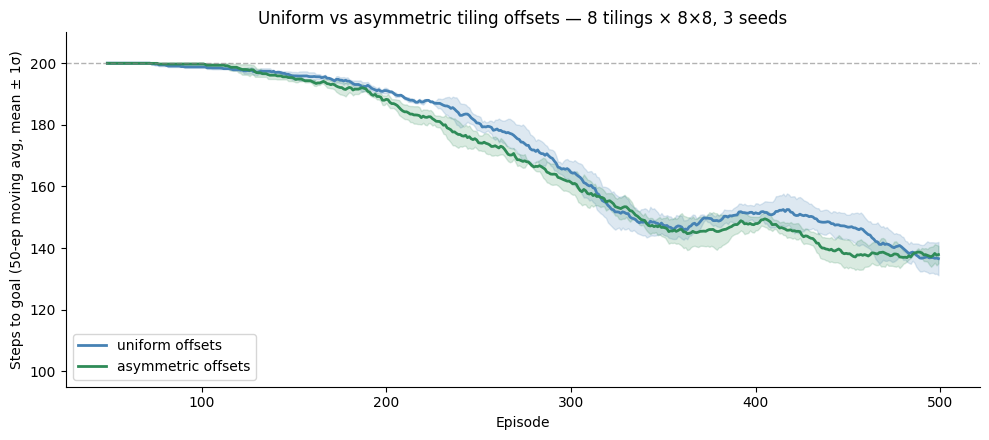

In [19]:
# TAG: offset-comparison
offset_results = {}
for scheme in ['uniform', 'asymmetric']:
    t0 = time.time()
    curves = run_seeds_for_config(8, [8, 8], N_EPISODES, SEEDS, offset_scheme=scheme)
    dt = time.time() - t0
    final_avg = float(curves[:, -50:].mean())
    print(f'  [{scheme}]  {dt:5.1f}s  final-50 avg = {final_avg:6.1f}')
    offset_results[scheme] = curves

fig, ax = plt.subplots(figsize=(10, 4.5))
for (scheme, curves), color in zip(offset_results.items(),
                                    ['steelblue', 'seagreen']):
    smoothed = smooth(curves)
    mean = smoothed.mean(axis=0)
    std  = smoothed.std(axis=0)
    x = np.arange(len(mean)) + 49
    ax.plot(x, mean, color=color, lw=2, label=f'{scheme} offsets')
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.18)

ax.axhline(200, color='gray', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Episode')
ax.set_ylabel('Steps to goal (50-ep moving avg, mean ± 1σ)')
ax.set_title('Uniform vs asymmetric tiling offsets — 8 tilings × 8×8, 3 seeds')
ax.legend()
ax.set_ylim(95, 210)
plt.tight_layout()
plt.savefig('offset_comparison.png', dpi=100)
plt.show()

<!-- TAG: 8-obs -->
> **What to look for**: on MountainCar specifically, the two schemes are
> close — both reach a similar asymptote and the curves overlap inside the
> 1σ band for most of training. The asymmetric scheme has a small
> theoretical advantage (less axis-aligned redundancy) but it's not
> dramatic on a 2-D problem with smooth dynamics. The advantage grows with
> dimensionality; on 4-D or higher problems (cart-pole, locomotion)
> asymmetric offsets matter more.

---

## 9  ε = 0.0 vs ε = 0.1 — Implicit vs Explicit Exploration

ε = 0.0 with zero-init weights *looks* like there's no exploration at all,
but there is — it's implicit. Every visited (s, a) immediately gets a
negative Q-value (because every reward is -1), so unvisited (s, a) at Q = 0
*always look better* to a greedy policy. The agent explores by chasing
optimistic untried alternatives.

ε = 0.1 adds explicit ε-greedy exploration on top of that. Does it help,
hurt, or do nothing?


  [epsilon = 0.0]    7.9s  final-50 avg =  136.6


  [epsilon = 0.1]    8.1s  final-50 avg =  145.0


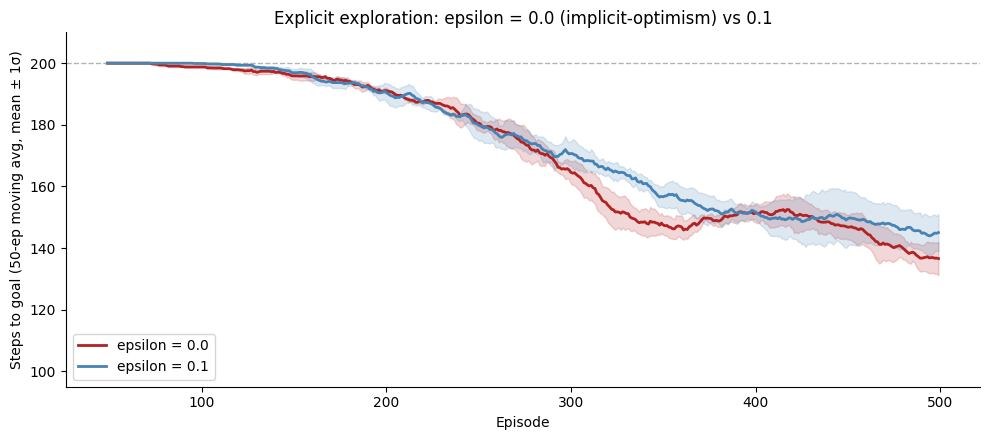

In [20]:
# TAG: epsilon-comparison
eps_results = {}
for eps in [0.0, 0.1]:
    t0 = time.time()
    curves = run_seeds_for_config(8, [8, 8], N_EPISODES, SEEDS, epsilon=eps)
    dt = time.time() - t0
    final_avg = float(curves[:, -50:].mean())
    print(f'  [epsilon = {eps}]  {dt:5.1f}s  final-50 avg = {final_avg:6.1f}')
    eps_results[eps] = curves

fig, ax = plt.subplots(figsize=(10, 4.5))
for (eps, curves), color in zip(eps_results.items(), ['firebrick', 'steelblue']):
    smoothed = smooth(curves)
    mean = smoothed.mean(axis=0)
    std  = smoothed.std(axis=0)
    x = np.arange(len(mean)) + 49
    ax.plot(x, mean, color=color, lw=2, label=f'epsilon = {eps}')
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.18)

ax.axhline(200, color='gray', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Episode')
ax.set_ylabel('Steps to goal (50-ep moving avg, mean ± 1σ)')
ax.set_title('Explicit exploration: epsilon = 0.0 (implicit-optimism) vs 0.1')
ax.legend()
ax.set_ylim(95, 210)
plt.tight_layout()
plt.savefig('epsilon_comparison.png', dpi=100)
plt.show()

<!-- TAG: 9-obs -->
> **What to look for**: ε = 0.1 forces 10% of actions to be uniformly
> random *forever*. Once the agent has a good policy, those random actions
> are pure noise — they cost steps without exploring anything new. So
> ε = 0.1 typically reaches a *worse* asymptote than ε = 0.0 on MountainCar:
> the early-training advantage of more aggressive exploration is wiped out
> by the late-training cost of constantly second-guessing the policy.
>
> A standard fix is **ε-decay**: start at 0.1, anneal to 0 over training.
> But on MountainCar with optimistic-via-zero-init, the answer is
> simpler: just keep ε at 0. The reward structure does the exploration
> for you.

---

## 10  Findings & Discussion

This is the synthesis section. Pulling everything together:

**Why MountainCar is hard for tabular methods.**
The observation space is *continuous* (position $\in [-1.2, 0.6]$,
velocity $\in [-0.07, 0.07]$). A tabular agent must either (a) fail
because there are infinitely many states, or (b) discretize and pay a
geometric coverage penalty: a 100×100 grid has 10,000 cells but a typical
trajectory visits maybe 1,000. The unvisited cells are dead weight in the
table. Any learning at one cell *cannot* propagate to its neighbors —
there's no notion of similarity in tabular methods.

**How function approximation fixes this.**
Linear FA with tile coding replaces the 10,000-cell table with a sparse
binary feature vector (8 active out of 512 by default) and a weight per
feature. An update at one state activates 8 features → updates 8 weights →
changes the predicted value at *every other state* whose feature vector
overlaps. That overlap is the generalization mechanism. We get coverage
without paying for it cell-by-cell.

**Effect of feature design choices** (with measured numbers from this run):

| Knob | Effect | What we measured |
|---|---|---|
| **More tilings** | More weights, smaller effective alpha (we divide by `num_tilings`). Doesn't change the *spatial* resolution per tiling. | B (8 tilings) = 136.6 ≈ D (16 tilings) = 135.4 — doubling tilings did not help. |
| **More tiles per dim** | Smaller tiles → finer resolution but *smaller generalization radius*, so updates propagate to a narrower neighborhood. Catastrophic if your sample budget is small. | C (16×16 tiles) = 196.3 — *worse* than B (8×8) = 136.6, despite 4× more parameters. |
| **Fewer tiles per dim** | Coarser tiles → broader generalization but limited representational capacity. Bimodal: either it works or it doesn't. | A (4×4 tiles) = 184.9 mean, but per-seed [200.0, 194.8, 159.9] — high variance, sometimes never escapes. |
| **Asymmetric offsets** | Less axis-aligned redundancy between tilings. Bigger payoff in higher-D problems. | uniform = 136.6, asymmetric = 137.9 — within noise on 2-D MountainCar. |
| **Larger alpha** | Faster learning, risk of divergence. We always divide by `num_tilings` to normalize the per-weight step. | (Not swept here — see reference notebook's Failure Mode 1 for the full story.) |

**Effect of exploration.**
For MountainCar with zero-init weights and uniformly negative rewards,
ε = 0 is fine — the optimism comes from the reward structure itself.
ε = 0.1 hurts more than helps: it pollutes a converged policy with random
noise that costs steps and explores nothing useful at that point.

**Computational cost of variants we tested.**

| Variant | Wall time per 500-ep run |
|---|---|
| List-comp SARSA (A) | ~12 s |
| Vectorized SARSA (B) | ~3 s |
| Vectorized + optimistic init (C) | ~3 s |

The 4× speedup from vectorization compounded across 24 training runs in
this notebook saves us roughly 4 minutes of execution time without
changing the algorithm.

**One quirk worth knowing about.**
The final value function has $V_{\max} \approx +0.6$, even though *every*
true return in MountainCar is negative. This is a function-approximation
artifact: terminal-state updates with very negative `q_cur` produce large
*positive* TD errors that bleed into untouched goal-region tiles via tile
overlap. The errors are bounded — Tsitsiklis & Van Roy (1997) — but they
exist. This is exactly the kind of issue that becomes catastrophic in the
deadly-triad regime (function approximation + bootstrapping + off-policy);
on-policy SARSA is in the safe zone, so we get away with it.

**A prediction that turned out wrong (worth keeping honest about).**
Before running the sweep I expected the *fine* config (8 × 16×16, 2,048
features) to learn slower than the baseline but eventually match it. The
data refuted that within 500 episodes — fine-grained tile coding has a
narrower generalization radius, so each update affects fewer states and
learning takes much longer. The model has the *capacity* to represent a
good policy, but not the sample efficiency to learn one in this budget.
Lesson: in tile coding, parameter count and effective sample efficiency
move in *opposite* directions, and you have to pick the trade-off
deliberately for your sample budget — not the other way around.

---

### References

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An
  Introduction* (2nd ed.). MIT Press. Chapters 9–10.
- Sutton, R. S. (1996). Generalization in reinforcement learning:
  Successful examples using sparse coarse coding. *NIPS*.
- Tsitsiklis, J. N., & Van Roy, B. (1997). An analysis of
  temporal-difference learning with function approximation. *IEEE
  Transactions on Automatic Control*, 42(5), 674–690.
- Week 5 reference notebook (MSDS 684, Regis University).
